
# Mini-YOLO Fine-Tuning on KITTI Dataset

In the last notebook, we have trained a **Mini-YOLO** model from scratch to detect synthetic shapes like triangles or circles. Now let's challenge our model and see how it performs on real images! 
We will fine-tune the Mini-YOLO model on a subset of the KITTI dataset to detect objects of three classes in real images: Car, Pedestrian, and Cyclist.

**Steps we will complete:**
- Download and extract KITTI images and labels
- Parse labels for selected classes
- Encode YOLO targets (cell-relative)
- Fine-tune Mini-YOLO
- Visualize predictions (with optional NMS)


In [1]:

import os, zipfile, urllib.request, random
from glob import glob

import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import cv2
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


## 1) Download KITTI images and labels

First, we need to get the data:

In [3]:
from pathlib import Path
import urllib.request
import zipfile

DATA_ROOT = Path("data")
DATA_ROOT.mkdir(exist_ok=True)

# Where KITTI training data should live AFTER extraction
KITTI_TRAIN_DIR = DATA_ROOT / "training"

IMAGES_DIR = KITTI_TRAIN_DIR / "image_2"
LABELS_DIR = KITTI_TRAIN_DIR / "label_2"

IMG_ZIP = DATA_ROOT / "kitti_images.zip"
LBL_ZIP = DATA_ROOT / "kitti_labels.zip"


In [4]:
images_ok = IMAGES_DIR.exists() and len(list(IMAGES_DIR.glob("*.png"))) > 0
labels_ok = LABELS_DIR.exists() and len(list(LABELS_DIR.glob("*.txt"))) > 0

if images_ok and labels_ok:
    print("KITTI images and labels already present — skipping download.")


In [5]:
if not images_ok:
    if not IMG_ZIP.exists():
        print("Downloading KITTI images ...")
        urllib.request.urlretrieve(
            "https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_image_2.zip",
            IMG_ZIP.as_posix()
        )
        print("Images downloaded.")

    print("Extracting KITTI images ...")
    with zipfile.ZipFile(IMG_ZIP, "r") as zf:
        zf.extractall(DATA_ROOT)
    print("Images extracted.")

if not labels_ok:
    if not LBL_ZIP.exists():
        print("Downloading KITTI labels ...")
        urllib.request.urlretrieve(
            "https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_label_2.zip",
            LBL_ZIP.as_posix()
        )
        print("Labels downloaded.")

    print("Extracting KITTI labels ...")
    with zipfile.ZipFile(LBL_ZIP, "r") as zf:
        zf.extractall(DATA_ROOT)
    print("Labels extracted.")


Extracting KITTI images ...


Images extracted.
Extracting KITTI labels ...


Labels extracted.


In [6]:
assert IMAGES_DIR.exists(), f"Image directory not found: {IMAGES_DIR}"
assert LABELS_DIR.exists(), f"Label directory not found: {LABELS_DIR}"

n_imgs = len(list(IMAGES_DIR.glob("*.png")))
n_lbls = len(list(LABELS_DIR.glob("*.txt")))

print(f"KITTI images found: {n_imgs}")
print(f"KITTI labels found: {n_lbls}")

assert n_imgs > 0, "No KITTI images found after extraction!"
assert n_lbls > 0, "No KITTI labels found after extraction!"


KITTI images found: 7481
KITTI labels found: 7481


## 2) Mini-YOLO architecture

Now we define our Mini-YOLO architecture like before - please refer to the last Jupyter notebook for further details!

In [7]:
# MiniYOLO model definition
class MiniYOLO(nn.Module):
    def __init__(self, grid_size=7):
        super().__init__()
        self.S = grid_size
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 32, 7, stride=2, padding=3), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 5, 1)
        )
    def forward(self, x):
        f = self.backbone(x)
        h = self.head(f)
        h = F.interpolate(h, size=(self.S, self.S), mode="bilinear", align_corners=False)
        return torch.sigmoid(h).permute(0,2,3,1)


We load the pretrained weights from our previous training on synthetic shapes:

In [8]:
S = 7
IMG_SIZE = 128

model = MiniYOLO(S).to(device)
weights_path = "mini_yolo_shapes.pth"
if os.path.exists(weights_path):
    model.load_state_dict(torch.load(weights_path, map_location=device))
    print("Loaded pretrained weights from", weights_path)
else:
    print("No pretrained weights found — training will start from scratch.")


Loaded pretrained weights from mini_yolo_shapes.pth


## 3) Dataset and label parsing

We will train three classes here: car, pedestrian and cyclist. Since KITTI contains many more classes, we need to prepare our dataset:

In [9]:

SELECTED_CLASSES = {"Car", "Pedestrian", "Cyclist"}

def parse_kitti_label_file(label_path):
    """Parse a KITTI label file and return a list of [x1,y1,x2,y2] for selected classes."""
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 8:
                continue
            cls = parts[0]
            if cls not in SELECTED_CLASSES:
                continue
            # bbox: left, top, right, bottom
            x1, y1, x2, y2 = map(float, parts[4:8])
            boxes.append([x1, y1, x2, y2])
    return boxes

def resize_boxes_to_target(boxes, orig_w, orig_h, target_size=IMG_SIZE):
    """Scale original KITTI boxes to the resized image (IMG_SIZE x IMG_SIZE)."""
    if len(boxes) == 0:
        return np.zeros((0,4), dtype=np.float32)
    boxes = np.array(boxes, dtype=np.float32)
    sx = target_size / float(orig_w)
    sy = target_size / float(orig_h)
    boxes[:, [0,2]] *= sx  # x1, x2
    boxes[:, [1,3]] *= sy  # y1, y2
    return boxes

def encode_yolo_targets_from_boxes(boxes, grid_size=S, img_size=IMG_SIZE):
    """Encode multiple boxes into (S,S,5) with cell-relative offsets (one box per cell)."""
    y = torch.zeros((grid_size, grid_size, 5), dtype=torch.float32)
    if boxes.shape[0] == 0:
        return y
    x1, y1, x2, y2 = boxes[:,0], boxes[:,1], boxes[:,2], boxes[:,3]
    xc = ((x1 + x2) / 2) / img_size
    yc = ((y1 + y2) / 2) / img_size
    w  = (x2 - x1) / img_size
    h  = (y2 - y1) / img_size
    cell_x = np.clip((xc * grid_size).astype(int), 0, grid_size-1)
    cell_y = np.clip((yc * grid_size).astype(int), 0, grid_size-1)
    x_rel = xc * grid_size - cell_x
    y_rel = yc * grid_size - cell_y
    for cx, cy, xr, yr, wv, hv in zip(cell_x, cell_y, x_rel, y_rel, w, h):
        y[cy, cx] = torch.tensor([xr, yr, wv, hv, 1.0])
    return y

class KittiRealDataset(Dataset):
    def __init__(self, root=DATA_ROOT, n=250):
        img_dir = root / "training" / "image_2"
        lbl_dir = root / "training" / "label_2"

        img_paths = sorted(img_dir.glob("*.png"))[:n]
        lbl_paths = sorted(lbl_dir.glob("*.txt"))[:n]

        assert len(img_paths) > 0, f"No images found in {img_dir}"
        assert len(lbl_paths) > 0, f"No labels found in {lbl_dir}"

        self.samples = list(zip(img_paths, lbl_paths))
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        img_path, lbl_path = self.samples[idx]
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            # Fallback to blank if read fails
            img_bgr = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
            orig_h, orig_w = IMG_SIZE, IMG_SIZE
            boxes = []
        else:
            orig_h, orig_w = img_bgr.shape[:2]
            boxes = parse_kitti_label_file(lbl_path)

        # Resize image to square 128
        img_bgr = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        # Scale boxes accordingly
        boxes_resized = resize_boxes_to_target(boxes, orig_w, orig_h, IMG_SIZE)
        # Encode YOLO targets (cell-relative)
        y = encode_yolo_targets_from_boxes(boxes_resized, grid_size=S, img_size=IMG_SIZE)

        # Convert to tensor (CHW, RGB, [0,1])
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_t = torch.from_numpy(img_rgb.astype(np.float32)/255.).permute(2,0,1)

        return img_t, y


Now let's create training and validation loaders. You can increase the data sizes `n` to get improved results.

In [10]:
# Create datasets and dataloaders
train_ds = KittiRealDataset(n=3000)
val_ds   = KittiRealDataset(n=700)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)

print(f"Train/Val sizes: {len(train_ds)} / {len(val_ds)} (change n=... to use more) ")


Train/Val sizes: 3000 / 700 (change n=... to use more) 


## 4) YOLO-style loss

Here we define our YOLO loss. Note that we are using a different loss function now because the KITTI dataset is far more complex than the synthetic shapes dataset. We still use an MSE-based YOLOv1-style loss, but we apply several modifications to make training more stable on real-world data.
The loss separates the coordinate terms into an $x$, $y$ loss and a $\sqrt w$, $\sqrt h$ loss, which is a classic YOLOv1 trick to reduce the impact of large bounding boxes.
Object cells are weighted more strongly than non-object cells, and the entire loss is additionally scaled to stabilize gradients.
Although this formulation differs from the simpler loss used for synthetic shapes, it is still a regression-based YOLOv1 loss.

Let each prediction be 
$(\hat{x}_i, \hat{y}_i, \hat{w}_i, \hat{h}_i, \hat{c}_i)$
and the corresponding ground truth
$(x_i, y_i, w_i, h_i, c_i)$,
with $c_i \in \{0,1\}$ indicating object presence.
The total loss consists of coordinate loss, size loss,
objectness loss, and a penalty for non-object cells:

$$
\mathcal{L}
= 0.1 \Bigg(
\lambda_{\mathrm{coord}} \, \mathcal{L}_{xy}
+ \lambda_{\mathrm{coord}} \, \mathcal{L}_{wh}
+ 2 \, \mathcal{L}_{\mathrm{obj}}
+ \lambda_{\mathrm{noobj}} \, \mathcal{L}_{\mathrm{noobj}}
\Bigg).
$$

Let's take a closer look at the components. The **Coordinate Loss** for $x$ and $y$ uses Mean Squared Error:
$$
\mathcal{L}_{xy}
=
\frac{1}{N_{\mathrm{obj}}}
\sum_{i \in \mathrm{obj}}
\left[
(\hat{x}_i - x_i)^2
+
(\hat{y}_i - y_i)^2
\right].
$$

Width and height losses are calculated similarly, but with a square root to reduce the impact of large bounding boxes:
$$
\mathcal{L}_{wh}
=
\frac{1}{N_{\mathrm{obj}}}
\sum_{i \in \mathrm{obj}}
\left[
\left(\sqrt{\hat{w}_i} - \sqrt{w_i}\right)^2
+
\left(\sqrt{\hat{h}_i} - \sqrt{h_i}\right)^2
\right].
$$

As before, the **Objectness Loss** and **No-Object Loss** are defined as
$$
\mathcal{L}_{\mathrm{obj}}
=
\frac{1}{N_{\mathrm{obj}}}
\sum_{i \in \mathrm{obj}}
(\hat{c}_i - 1)^2
$$

and
$$
\mathcal{L}_{\mathrm{noobj}}
=
\frac{1}{N_{\mathrm{noobj}}}
\sum_{i \in \mathrm{noobj}}
(\hat{c}_i - 0)^2 .
$$


In [11]:
# Define YOLO loss function
def yolo_loss(pred, target, lambda_coord=3.0, lambda_noobj=2.0):
    obj_mask = target[..., 4] > 0.5 # object present
    noobj_mask = ~obj_mask # no object present

    if obj_mask.any():
        # Compute coordinate losses only for cells with objects
        xy_loss = lambda_coord * F.mse_loss(pred[obj_mask][..., :2], target[obj_mask][..., :2])
        wh_loss = lambda_coord * F.mse_loss(
            torch.sqrt(pred[obj_mask][..., 2:4].clamp(1e-6, 1.0)),
            torch.sqrt(target[obj_mask][..., 2:4].clamp(1e-6, 1.0))
        )
        # Objectness loss for cells with objects, weighted higher
        obj_loss = 2.0 * F.mse_loss(pred[obj_mask][..., 4], target[obj_mask][..., 4])
    else:
        xy_loss = wh_loss = obj_loss = torch.tensor(0., device=pred.device)

    # Objectness loss for cells without objects, weighted lower
    noobj_loss = lambda_noobj * F.mse_loss(pred[noobj_mask][..., 4], target[noobj_mask][..., 4])
    
    # Return scaled total loss
    return 0.1 * (xy_loss + wh_loss + obj_loss + noobj_loss)


## 5) Fine-tuning

**TODO:** Now it's your turn! Define an optimizer - remember that for fine-tuning, we use a rather low learning rate. Then, train the model and print the validation loss every epoch.

In [12]:
# YOUR CODE HERE

# Define ADAM optimizer with a low learning rate
opt = torch.optim.Adam(model.parameters(), lr=1e-4)

# Evaluation function
def evaluate(loader):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            p = model(x)
            total += yolo_loss(p, y).item()
    return total / max(1, len(loader))

# Training loop
EPOCHS = 50
for epoch in range(1, EPOCHS+1):
    model.train()
    running = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        p = model(x)
        loss = yolo_loss(p, y)
        opt.zero_grad(); loss.backward(); opt.step()
        running += loss.item()
    val_loss = evaluate(val_loader)
    print(f"Epoch {epoch:02d} | Train={running/len(train_loader):.4f} | Val={val_loss:.4f}")


Epoch 01 | Train=0.0952 | Val=0.0601


Epoch 02 | Train=0.0534 | Val=0.0490


Epoch 03 | Train=0.0464 | Val=0.0442


Epoch 04 | Train=0.0425 | Val=0.0405


Epoch 05 | Train=0.0397 | Val=0.0380


...

Epoch 46 | Train=0.0075 | Val=0.0070


Epoch 47 | Train=0.0073 | Val=0.0069


Epoch 48 | Train=0.0071 | Val=0.0074


Epoch 49 | Train=0.0073 | Val=0.0088


Epoch 50 | Train=0.0067 | Val=0.0067


## 6) Postprocessing and Evaluation

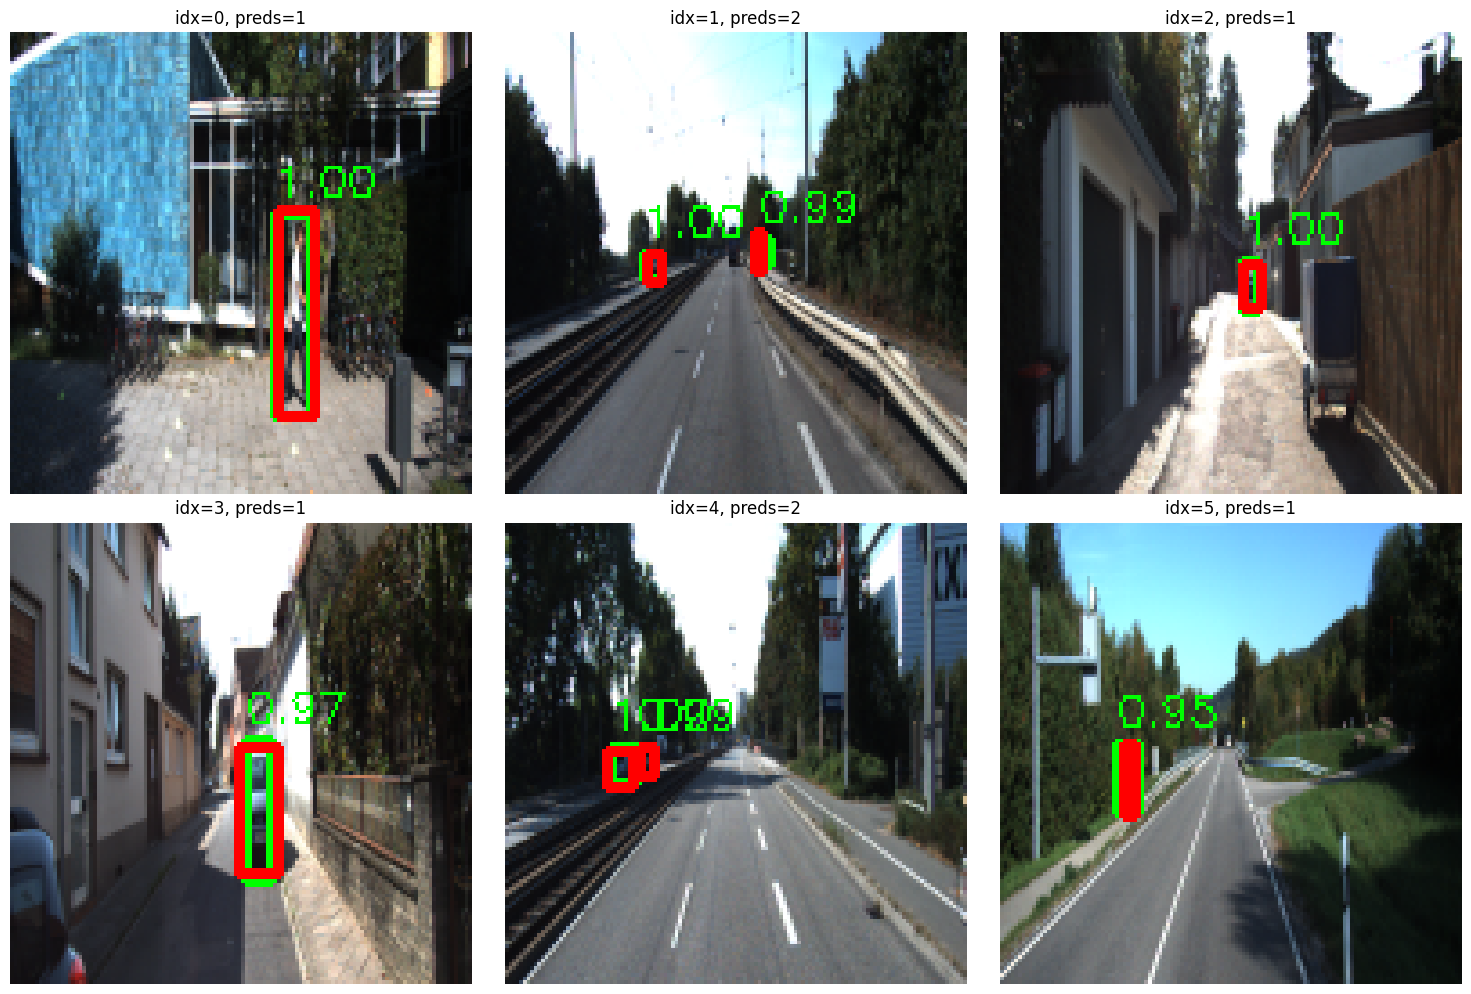

In [13]:

import torchvision.ops as ops

def yolo_postprocess(pred, conf_thresh=0.5, iou_thresh=0.3):
    """Convert (S,S,5) to pixel boxes with NMS."""
    S_ = pred.shape[0]
    boxes, scores = [], []
    
    # Convert cell-relative predictions to global image coordinates
    for cy in range(S_):
        for cx in range(S_):
            x_rel, y_rel, w, h, conf = pred[cy, cx]
            if conf < conf_thresh:
                continue

            # Convert to global normalized coordinates
            x = (cx + x_rel) / S_
            y = (cy + y_rel) / S_
            
            # Convert to absolute pixel coordinates
            x1 = (x - w/2) * IMG_SIZE
            y1 = (y - h/2) * IMG_SIZE
            x2 = (x + w/2) * IMG_SIZE
            y2 = (y + h/2) * IMG_SIZE

            boxes.append([x1, y1, x2, y2])
            scores.append(conf)

    if len(boxes) == 0:
        return np.zeros((0,4), dtype=np.float32), np.zeros((0,), dtype=np.float32)
    
    boxes_t = torch.tensor(boxes, dtype=torch.float32)
    scores_t = torch.tensor(scores, dtype=torch.float32)
    
    # Apply Non-Maximum Suppression
    keep = ops.nms(boxes_t, scores_t, iou_thresh)

    return boxes_t[keep].numpy(), scores_t[keep].numpy()

def visualize_prediction_grid(model, dataset, idx_list, conf_thresh=0.5, iou_thresh=0.3):
    """
    Visualize 6 samples in a 3x2 grid.
    idx_list: list of 6 indices from the dataset.
    """
    assert len(idx_list) == 6, "Please provide exactly 6 indices."

    model.eval()
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    for ax, idx in zip(axes.flatten(), idx_list):
        img_t, tgt = dataset[idx]

        # Forward pass
        with torch.no_grad():
            pred = model(img_t.unsqueeze(0).to(device))[0].cpu().numpy()

        boxes, scores = yolo_postprocess(pred, conf_thresh, iou_thresh)

        # Convert to uint8 image
        img = (img_t.permute(1,2,0).numpy() * 255).astype(np.uint8).copy()

        # Draw predicted boxes (green)
        for (x1, y1, x2, y2), s in zip(boxes.astype(int), scores):
            cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
            cv2.putText(img, f"{s:.2f}", (x1, max(10, y1-5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,255,0), 1)

        # Decode GT boxes (red)
        gt_boxes = []
        y = tgt.numpy()
        S_ = y.shape[0]
        for cy in range(S_):
            for cx in range(S_):
                if y[cy, cx, 4] > 0.5:
                    xr, yr, w, h = y[cy, cx, :4]
                    x = (cx + xr) / S_
                    yy = (cy + yr) / S_
                    x1 = int((x - w/2) * IMG_SIZE)
                    y1 = int((yy - h/2) * IMG_SIZE)
                    x2 = int((x + w/2) * IMG_SIZE)
                    y2 = int((yy + h/2) * IMG_SIZE)
                    gt_boxes.append([x1, y1, x2, y2])

        for (x1, y1, x2, y2) in gt_boxes:
            cv2.rectangle(img, (x1, y1), (x2, y2), (255,0,0), 2)

        # Plot
        ax.imshow(img)
        ax.set_title(f"idx={idx}, preds={len(boxes)}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# Visualize predictions on selected validation samples
visualize_prediction_grid(
    model,
    val_ds,
    idx_list=[0, 1, 2, 3, 4, 5],
    conf_thresh=0.8,
    iou_thresh=0.1
)